In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 257kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


In [ ]:
class DeepFFNN(nn.Module):
    def __init__(self):
        super(DeepFFNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)   # Flatten image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.out(x)
        return x


In [ ]:
model = DeepFFNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/10], Loss: 482.0488, Accuracy: 81.21%
Epoch [2/10], Loss: 350.3004, Accuracy: 86.39%
Epoch [3/10], Loss: 314.7156, Accuracy: 87.67%
Epoch [4/10], Loss: 293.8522, Accuracy: 88.42%
Epoch [5/10], Loss: 274.8815, Accuracy: 89.18%
Epoch [6/10], Loss: 259.6288, Accuracy: 89.69%
Epoch [7/10], Loss: 245.2438, Accuracy: 90.17%
Epoch [8/10], Loss: 235.9151, Accuracy: 90.53%
Epoch [9/10], Loss: 227.0853, Accuracy: 90.86%
Epoch [10/10], Loss: 214.9601, Accuracy: 91.37%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 88.85%


In [ ]:
class FFNN_1Layer(nn.Module):
    def __init__(self):
        super(FFNN_1Layer, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.out = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.out(x)
        return x


In [ ]:
model = DeepFFNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/10], Loss: 485.6544, Accuracy: 81.30%
Epoch [2/10], Loss: 352.3360, Accuracy: 86.25%
Epoch [3/10], Loss: 318.0616, Accuracy: 87.52%
Epoch [4/10], Loss: 294.2801, Accuracy: 88.34%
Epoch [5/10], Loss: 274.6813, Accuracy: 89.16%
Epoch [6/10], Loss: 263.2045, Accuracy: 89.61%
Epoch [7/10], Loss: 245.8818, Accuracy: 90.23%
Epoch [8/10], Loss: 233.8588, Accuracy: 90.66%
Epoch [9/10], Loss: 224.0399, Accuracy: 91.12%
Epoch [10/10], Loss: 216.9006, Accuracy: 91.25%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 87.54%


5 hidden layers


In [ ]:
class FFNN_5Layer(nn.Module):
    def __init__(self):
        super(FFNN_5Layer, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        x = self.out(x)
        return x


In [ ]:
model = DeepFFNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


Epoch [1/10], Loss: 205.2165, Accuracy: 91.89%
Epoch [2/10], Loss: 197.0745, Accuracy: 92.06%
Epoch [3/10], Loss: 189.1173, Accuracy: 92.42%
Epoch [4/10], Loss: 181.0640, Accuracy: 92.66%
Epoch [5/10], Loss: 175.5348, Accuracy: 92.89%
Epoch [6/10], Loss: 166.5870, Accuracy: 93.26%
Epoch [7/10], Loss: 160.2477, Accuracy: 93.53%
Epoch [8/10], Loss: 156.1581, Accuracy: 93.65%
Epoch [9/10], Loss: 146.9720, Accuracy: 94.07%
Epoch [10/10], Loss: 142.3820, Accuracy: 94.23%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 88.55%


advanced task 3:


In [ ]:
class DeepFFNN_Visual(nn.Module):
    def __init__(self):
        super(DeepFFNN_Visual, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        output = self.out(h3)

        return output, h1, h2, h3


In [ ]:
import matplotlib.pyplot as plt

data_iter = iter(test_loader)
images, labels = next(data_iter)

sample_img = images[0].to(device)
sample_label = labels[0].item()


In [ ]:
model = DeepFFNN_Visual().to(device)
model.eval()

with torch.no_grad():
    output, h1, h2, h3 = model(sample_img.unsqueeze(0))


In [ ]:
def plot_activations(activations, title):
    activations = activations.cpu().numpy().flatten()[:16]
    plt.figure(figsize=(6,2))
    plt.bar(range(len(activations)), activations)
    plt.title(title)
    plt.xlabel("Neuron Index")
    plt.ylabel("Activation Value")
    plt.show()


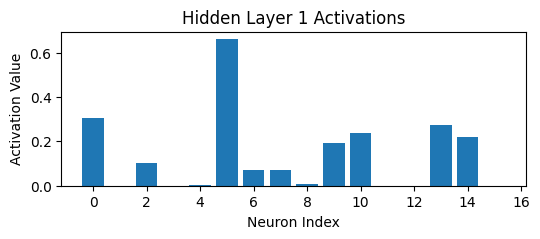

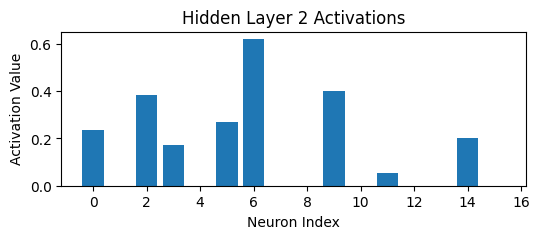

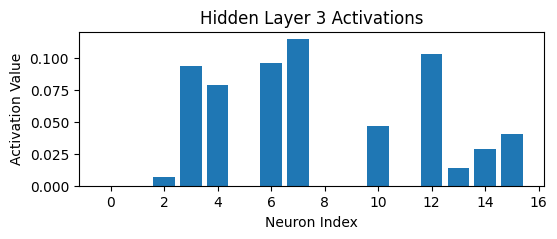

In [ ]:
plot_activations(h1, "Hidden Layer 1 Activations")
plot_activations(h2, "Hidden Layer 2 Activations")
plot_activations(h3, "Hidden Layer 3 Activations")


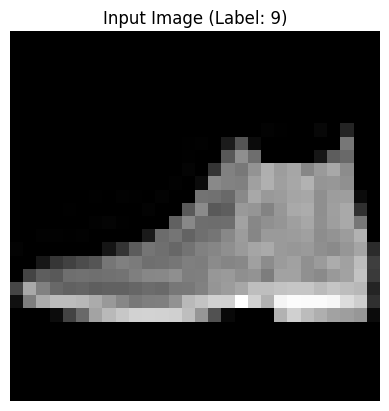

In [ ]:
plt.imshow(sample_img.cpu().squeeze(), cmap="gray")
plt.title(f"Input Image (Label: {sample_label})")
plt.axis("off")
plt.show()
